# Tarea práctica

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import torch
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn import metrics
from itertools import chain
from nltk import NaiveBayesClassifier


## Cargar el dataset

In [2]:
data = pd.read_csv("book_reviews_1000.csv", sep= ";", engine="python")
data.head()

,index,reviewText,rating
0,3001,The ending was strong and satisfying overall. ...,4
1,3002,"For me, this read was easy to follow but fairl...",3
2,3003,"For me, the story was beautifully written and ...",5
3,3004,"At first I had doubts, but this read was thoug...",5
4,3005,I did not enjoy the novel; it was disappointin...,1


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   index       1000 non-null   int64
 1   reviewText  1000 non-null   str  
 2   rating      1000 non-null   int64
dtypes: int64(2), str(1)
memory usage: 23.6 KB


In [4]:
data['reviewText'][0]

'The ending was strong and satisfying overall. It was a delightful surprise.'

## Limpiar el dataset

In [5]:
# minusculas
data['reviewText_clean'] = data['reviewText'].str.lower()

In [6]:
# eliminar puntuacion
data['reviewText_clean'] = data.apply(lambda x: re.sub(r"([^\w\s])", "", x['reviewText_clean']), axis=1)

In [7]:
data.head()

,index,reviewText,rating,reviewText_clean
0,3001,The ending was strong and satisfying overall. ...,4,the ending was strong and satisfying overall i...
1,3002,"For me, this read was easy to follow but fairl...",3,for me this read was easy to follow but fairly...
2,3003,"For me, the story was beautifully written and ...",5,for me the story was beautifully written and m...
3,3004,"At first I had doubts, but this read was thoug...",5,at first i had doubts but this read was though...
4,3005,I did not enjoy the novel; it was disappointin...,1,i did not enjoy the novel it was disappointing...


## Sentimiento basado en reglas con VADER

In [8]:
vader_sentiment = SentimentIntensityAnalyzer()

In [9]:
data['vader_sentiment_score'] = data['reviewText_clean'].apply(lambda review: vader_sentiment.polarity_scores(review)['compound'])

In [10]:
# creando datos
bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']

data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels=names)

<Axes: xlabel='vader_sentiment_label'>

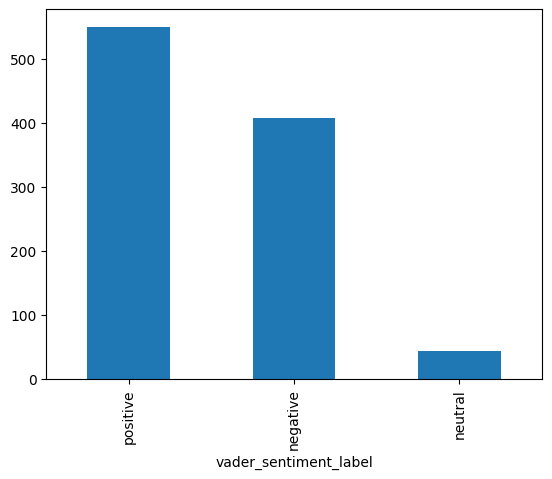

In [11]:
data['vader_sentiment_label'].value_counts().plot.bar()

## Modelo de transformador preentrenado

In [14]:
transformer_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [15]:
transformer_labels = []

for review in data['reviewText_clean'].values:
    sentiment_list = transformer_pipeline(review)
    sentiment_label = [sent['label'] for sent in sentiment_list]
    transformer_labels.append(sentiment_label)
    
data['transformer_sentiment_label'] = transformer_labels

<Axes: xlabel='transformer_sentiment_label'>

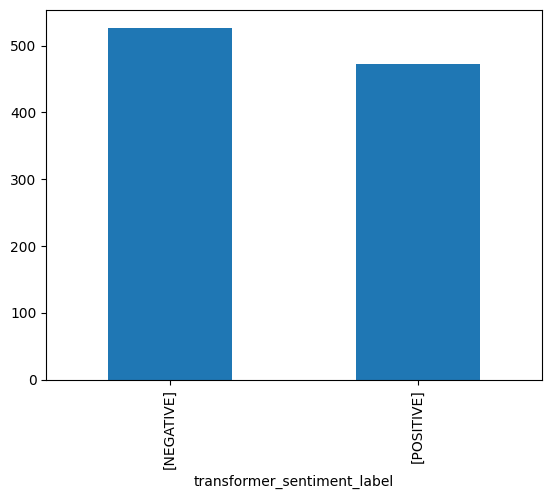

In [16]:
data['transformer_sentiment_label'].value_counts().plot.bar()